# Tier B / S1 — the double resuspension experiment

**Reference.** Sherwood, C. R. *et al.* (2018), Geosci. Model Dev. **11**,
1849–1871 — Section 3.2.1 and Figure 5.

**The case.** A 20 m column, one-dimensional in the vertical, flat bottom, no floc
dynamics. Two bottom-stress events about 1.5 days apart, lasting 1.5 and 1 days,
the first peaking near 1 Pa. Four sediment classes, all initially in the bed.
Five days total.

**What Sherwood reports, and what we should reproduce:**

1. The finer fractions dominate the suspended load; the water column contains
   *"only a small fraction of the coarsest sand"*.
2. When the stress subsides, *"coarser sediment deposited first, while finer
   material remained suspended"* — building a fining-upward storm layer over a
   coarse lag.
3. *"The finest material (4 µm) remained mostly in suspension after 5 days."*
4. The second, weaker pulse *"only resuspended minimal amounts of the 140 µm
   sand"*.

**The adaptation.** ROMS has a layered bed and reports stratigraphy; we have no
bed layers. So the stratigraphic result — graded bedding, a lag layer — is
compared through **the order in which classes leave suspension**, which is what
builds it. Where a quantity is out of reach we say so rather than approximate it.

Tests: `tests/models/test_sppm_roms_cases.py` (the `test_s1_*` family)

In [1]:
# Tier B / S1 - double resuspension experiment
import sys, pathlib, warnings
warnings.filterwarnings("ignore")

# locate the repository root (the directory containing `opendrift/`)
_p = pathlib.Path.cwd().resolve()
while not (_p / "opendrift" / "__init__.py").exists() and _p != _p.parent:
    _p = _p.parent
REPO = _p
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

plt.rcParams.update({
    "figure.figsize": (9, 4.2), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.3,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "bold",
})
CLR = ["#0b6fa4", "#e07b39", "#3f9b52", "#b4434e", "#7c5aa6"]
print("repo:", REPO)

repo: /home/smullersoares/projects/software/opendrift


## Setup

### The four sediment classes

Diameters, critical stresses and settling velocities exactly as prescribed in
Section 3.2.1. Note the classes span an **80-fold** range of settling velocity —
that spread is what the deposition-order test exploits.

In [2]:
import datetime, tempfile, os
import xarray as xr
from tests.models.sppm_harness import column_dataset, column_model, stress_to_speed
from tests.models.test_sppm_roms_cases import CLASS_D, CLASS_TAU_CE, CLASS_WS, _s1_stress

NAMES = ['clay 4 µm', 'silt 30 µm', 'sand 62.5 µm', 'sand 140 µm']
H, HOURS, N_PER_CLASS = 20.0, 120.0, 500

print(f"{'class':>14s} {'d [µm]':>8s} {'τ_ce [Pa]':>10s} {'w_s [mm/s]':>11s} {'h/w_s [h]':>10s}")
for n, d, t, w in zip(NAMES, CLASS_D, CLASS_TAU_CE, CLASS_WS):
    print(f"{n:>14s} {d*1e6:8.1f} {t:10.2f} {w*1e3:11.1f} {H/w/3600:10.1f}")

         class   d [µm]  τ_ce [Pa]  w_s [mm/s]  h/w_s [h]
     clay 4 µm      4.0       0.05         0.1       55.6
    silt 30 µm     30.0       0.05         0.6        9.3
  sand 62.5 µm     62.5       0.10         2.0        2.8
   sand 140 µm    140.0       0.10         8.0        0.7


### The bottom-stress history

Two half-sine events. The forcing is imposed through the current: with the
`legacy` bed-stress scheme and a finely resolved column, the stress reduces to
$\tau_b = \rho\,c_d\,|u|^2$, so a prescribed stress history is exactly
invertible into a speed.

The dashed lines are the two threshold levels. Both events clear **both**
thresholds — which is precisely why the second event is the interesting one.

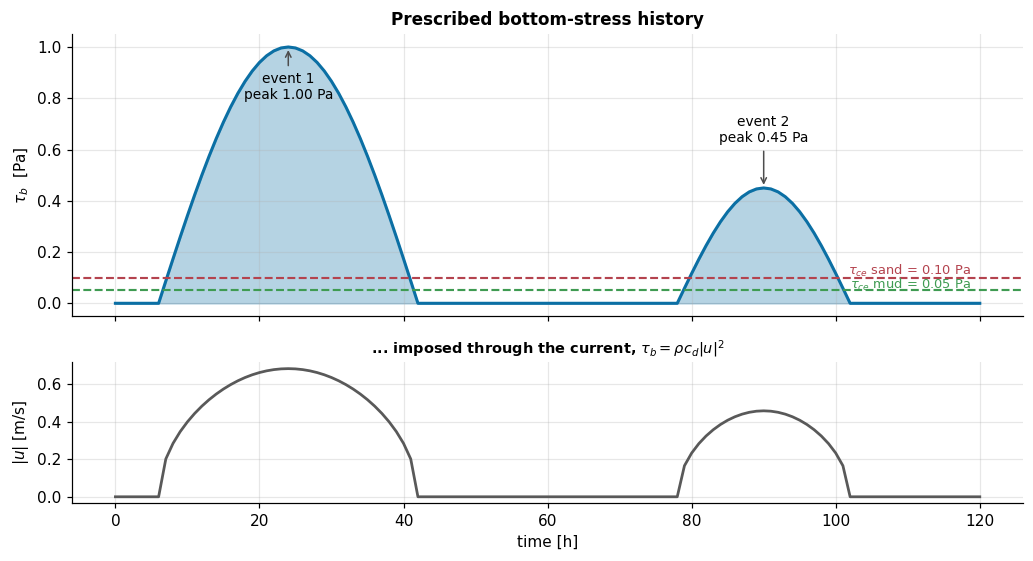

In [3]:
t_h, tau_h = _s1_stress(HOURS)
u_h = stress_to_speed(tau_h)

fig, (a1, a2) = plt.subplots(2, 1, figsize=(9.5, 5.2), sharex=True,
                             gridspec_kw={'height_ratios': [2, 1]})
a1.fill_between(t_h, 0, tau_h, color=CLR[0], alpha=.30)
a1.plot(t_h, tau_h, color=CLR[0], lw=2)
for lvl, lab, c in [(0.05, r'$\tau_{ce}$ mud = 0.05 Pa', CLR[2]),
                    (0.10, r'$\tau_{ce}$ sand = 0.10 Pa', CLR[3])]:
    a1.axhline(lvl, color=c, lw=1.4, ls='--')
    a1.text(HOURS * .99, lvl * 1.10, lab, ha='right', fontsize=8.5, color=c)
a1.set_ylabel(r'$\tau_b$  [Pa]'); a1.set_title('Prescribed bottom-stress history')
a1.annotate('event 1\npeak 1.00 Pa', xy=(24, 1.0), xytext=(0, -34),
            textcoords='offset points', ha='center', fontsize=9,
            arrowprops=dict(arrowstyle='->', color='0.3'))
a1.annotate('event 2\npeak 0.45 Pa', xy=(90, .45), xytext=(0, 30),
            textcoords='offset points', ha='center', fontsize=9,
            arrowprops=dict(arrowstyle='->', color='0.3'))
a2.plot(t_h, u_h, color='0.35', lw=1.8)
a2.set_ylabel('$|u|$ [m/s]'); a2.set_xlabel('time [h]')
a2.set_title(r'... imposed through the current, $\tau_b=\rho c_d |u|^2$', fontsize=9.5)
plt.tight_layout(); plt.show()

## Run

2000 elements, 500 per class, all starting **on the bed** (`z='seafloor'`,
`settled=1`). Five simulated days; this takes a few minutes.

In [4]:
ds = column_dataset(h=H, u=u_h, u_star=0.02, hours=HOURS, dt_hours=1.0, nz=81)
o, reader = column_model(
    ds,
    vertical_mixing__settling_model='prescribed',
    vertical_mixing__tau_crit_mode='constant',
    vertical_mixing__resuspension_height_mode='turbulent',
    vertical_mixing__bbl_scheme='legacy',
    vertical_mixing__resuspension_seed_layer=5.0)

np.random.seed(3)
n = N_PER_CLASS * 4
o.seed_elements(lon=8.0, lat=64.0, number=n, time=reader.start_time, z='seafloor',
                terminal_velocity=np.repeat(-CLASS_WS, N_PER_CLASS),
                tau_crit=np.repeat(CLASS_TAU_CE, N_PER_CLASS),
                grain_diameter=np.repeat(CLASS_D, N_PER_CLASS),
                rho_s=np.full(n, 2650.0), use_stokes=np.zeros(n),
                origin_marker=np.repeat(np.arange(4), N_PER_CLASS),
                settled=np.ones(n), moving=np.zeros(n))

out = os.path.join(tempfile.mkdtemp(), 's1.nc')
o.run(time_step=300, time_step_output=1800,
      duration=datetime.timedelta(hours=HOURS), outfile=out,
      export_variables=['z', 'settled', 'moving', 'origin_marker',
                        'times_resuspended'], stop_on_error=True)

with xr.open_dataset(out) as d:
    settled = d['settled'].values
    zz = d['z'].values
    marker = d['origin_marker'].values[:, 0].astype(int)
    resusp = d['times_resuspended'].values
hours = np.arange(settled.shape[1]) * 0.5
susp = np.array([[np.nanmean(settled[marker == k, i] == 0)
                  for i in range(settled.shape[1])] for k in range(4)])
print(f"lost from the domain: {int(np.sum(~np.isfinite(settled[:, -1])))} of {n}")

lost from the domain: 0 of 2000


## Result 1 — suspended load and its termination

This is the central figure. Shaded bands are the two stress events.

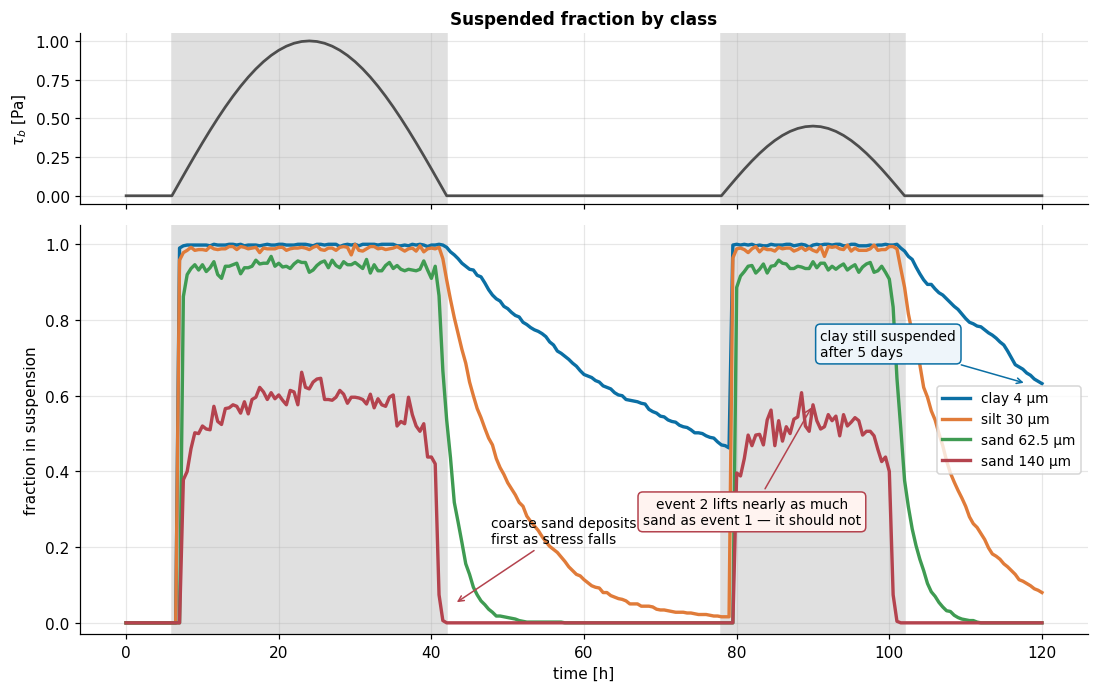

In [5]:
fig, (a1, a2) = plt.subplots(2, 1, figsize=(10, 6.4), sharex=True,
                             gridspec_kw={'height_ratios': [1, 2.4]})
for a in (a1, a2):
    for t0, t1 in [(6, 42), (78, 102)]:
        a.axvspan(t0, t1, color='0.88', zorder=0)
a1.plot(t_h, tau_h, color='0.3', lw=1.8); a1.set_ylabel(r'$\tau_b$ [Pa]')
a1.set_title('Suspended fraction by class')

for k, (nm, c) in enumerate(zip(NAMES, CLR)):
    a2.plot(hours, susp[k], color=c, lw=2.2, label=nm)
a2.set_xlabel('time [h]'); a2.set_ylabel('fraction in suspension')
a2.set_ylim(-.03, 1.05); a2.legend(loc='center right', fontsize=9)
a2.annotate('coarse sand deposits\nfirst as stress falls',
            xy=(43, .05), xytext=(24, 40), textcoords='offset points',
            fontsize=9, arrowprops=dict(arrowstyle='->', color=CLR[3]))
a2.annotate('clay still suspended\nafter 5 days', xy=(118, susp[0][-1]),
            xytext=(-135, 18), textcoords='offset points', fontsize=9,
            arrowprops=dict(arrowstyle='->', color=CLR[0]),
            bbox=dict(boxstyle='round,pad=0.35', fc='#eef5fa', ec=CLR[0]))
a2.annotate('event 2 lifts nearly as much\nsand as event 1 — it should not',
            xy=(90, susp[3][np.argmin(abs(hours - 90))]), xytext=(-40, -78),
            textcoords='offset points', fontsize=9, ha='center',
            arrowprops=dict(arrowstyle='->', color=CLR[3]),
            bbox=dict(boxstyle='round,pad=0.35', fc='#fff3f0', ec=CLR[3]))
plt.tight_layout(); plt.show()

### Deposition order

The order in which classes clear from suspension after event 1 ends is the
Lagrangian expression of the fining-upward storm layer.

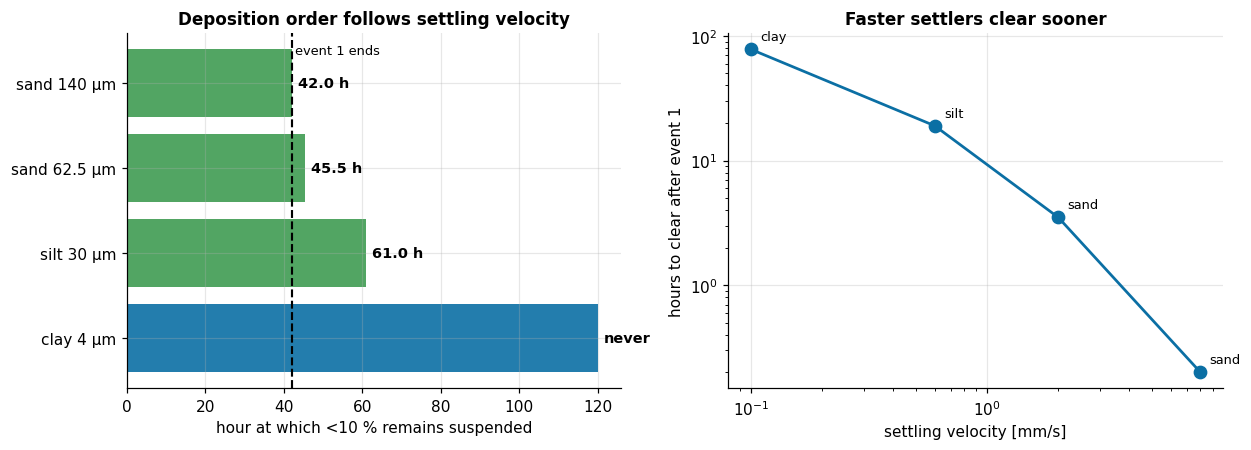

     clay 4 µm: never
    silt 30 µm: 61.0 h
  sand 62.5 µm: 45.5 h
   sand 140 µm: 42.0 h


In [6]:
clear_h = []
for k in range(4):
    after = np.where((hours >= 42) & (susp[k] < 0.10))[0]
    clear_h.append(hours[after[0]] if after.size else np.inf)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.5, 4.2))
lab = [f'{h:.1f} h' if np.isfinite(h) else 'never' for h in clear_h]
vals = [h if np.isfinite(h) else HOURS for h in clear_h]
a1.barh(NAMES, vals, color=[CLR[2] if np.isfinite(h) else CLR[0] for h in clear_h], alpha=.9)
a1.axvline(42, color='k', lw=1.4, ls='--')
a1.text(42.8, 3.35, 'event 1 ends', fontsize=8.5)
for i, (v, t) in enumerate(zip(vals, lab)):
    a1.text(v + 1.5, i, t, va='center', fontsize=9.5, fontweight='bold')
a1.set_xlabel('hour at which <10 % remains suspended')
a1.set_title('Deposition order follows settling velocity')

a2.loglog(CLASS_WS * 1e3, [max(h - 42, .2) for h in vals], 'o-',
          color=CLR[0], ms=8, lw=1.8)
for w, v, nm in zip(CLASS_WS * 1e3, vals, NAMES):
    a2.annotate(nm.split()[0], (w, max(v - 42, .2)), textcoords='offset points',
                xytext=(6, 6), fontsize=8.5)
a2.set_xlabel('settling velocity [mm/s]'); a2.set_ylabel('hours to clear after event 1')
a2.set_title('Faster settlers clear sooner')
plt.tight_layout(); plt.show()
for nm, t in zip(NAMES, lab):
    print(f'{nm:>14s}: {t}')

## Result 2 — where it fails

Two failures, sharing one cause: our resuspension is an **all-or-nothing
threshold crossing**, whereas ROMS erodes with a *flux*,
$E = E_0(1-\phi)(\tau_b/\tau_{ce}-1)$, which scales with the excess stress.

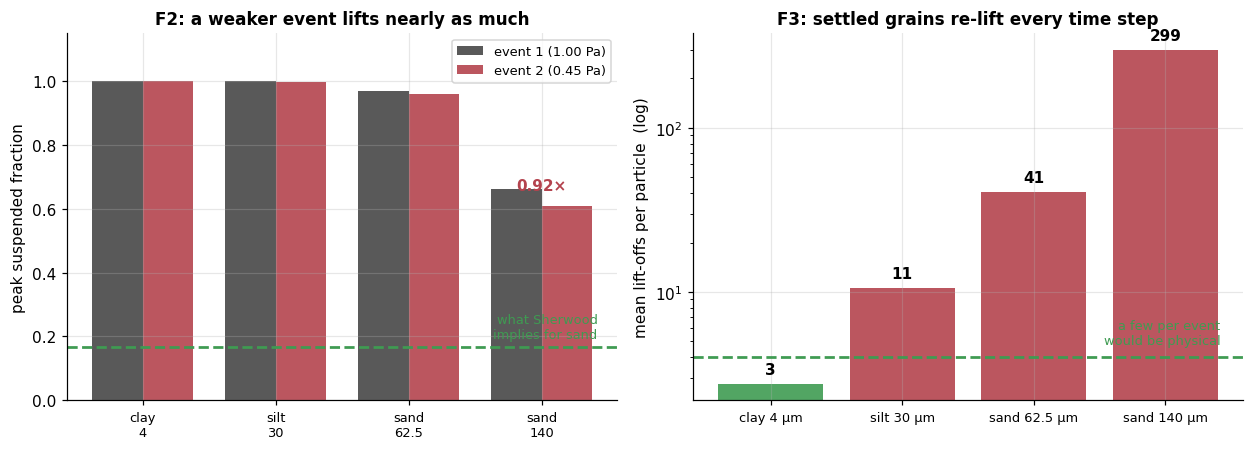

peak suspended fraction   event 1 / event 2 / ratio
       clay 4 µm  1.000  1.000   1.00
      silt 30 µm  1.000  0.998   1.00
    sand 62.5 µm  0.968  0.958   0.99
     sand 140 µm  0.662  0.608   0.92

mean lift-offs per particle: 4 3, 30 11, 62.5 41, 140 299


In [7]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.5, 4.2))

# --- F2: event-2 intensity is not suppressed
e1 = np.array([susp[k][(hours >= 6) & (hours <= 42)].max() for k in range(4)])
e2 = np.array([susp[k][(hours >= 78) & (hours <= 102)].max() for k in range(4)])
x = np.arange(4)
a1.bar(x - .19, e1, .38, color='0.35', label='event 1 (1.00 Pa)')
a1.bar(x + .19, e2, .38, color=CLR[3], alpha=.9, label='event 2 (0.45 Pa)')
a1.axhline(e1[3] * 0.25, color=CLR[2], lw=1.8, ls='--')
a1.text(3.42, e1[3] * 0.25 + .03, 'what Sherwood\nimplies for sand',
        ha='right', fontsize=8.5, color=CLR[2])
a1.set_xticks(x); a1.set_xticklabels([n.split()[0] + '\n' + n.split()[1] for n in NAMES],
                                     fontsize=8.5)
a1.set_ylabel('peak suspended fraction'); a1.set_ylim(0, 1.15)
a1.set_title('F2: a weaker event lifts nearly as much'); a1.legend(fontsize=8.5)
a1.text(3, e2[3] + .05, f'{e2[3]/e1[3]:.2f}×', ha='center', fontsize=10,
        fontweight='bold', color=CLR[3])

# --- F3: lift-offs per particle
per = []
for k in range(4):
    m = marker == k
    last = np.nanmax(np.where(np.isfinite(resusp[m]), resusp[m], np.nan), axis=1)
    per.append(np.nanmean(last))
a2.bar(NAMES, per, color=[CLR[2] if p < 5 else CLR[3] for p in per], alpha=.9)
a2.axhline(4, color=CLR[2], lw=1.8, ls='--')
a2.set_yscale('log')
a2.text(3.42, 4.8, 'a few per event\nwould be physical', ha='right',
        fontsize=8.5, color=CLR[2])
a2.set_ylabel('mean lift-offs per particle  (log)')
a2.set_title('F3: settled grains re-lift every time step')
for i, p in enumerate(per):
    a2.text(i, p * 1.15, f'{p:.0f}', ha='center', fontsize=10, fontweight='bold')
plt.setp(a2.get_xticklabels(), fontsize=8.5)
plt.tight_layout(); plt.show()

print('peak suspended fraction   event 1 / event 2 / ratio')
for nm, a, b in zip(NAMES, e1, e2):
    print(f'  {nm:>14s}  {a:.3f}  {b:.3f}   {b/a:.2f}')
print('\nmean lift-offs per particle:', ', '.join(f'{n.split()[1]} {p:.0f}' for n, p in zip(NAMES, per)))

## Verdict

**Four passes.**

| | Sherwood | model |
|---|---|---|
| Fines dominate the suspended load | yes | peak fraction falls monotonically with grain size |
| Coarse deposits first | yes | 140 µm → 62.5 → 30 µm, strictly ordered |
| 4 µm still suspended at day 5 | *"mostly"* | ~64 % |
| Mass conserved in the column | — | 0 elements lost |

**Two failures, one cause.**

- **F2 — event-intensity scaling.** The second event, at 0.45 Pa against a 0.10 Pa
  threshold, resuspends ~0.92× as much sand as the 1.00 Pa first event. Sherwood
  gets *"minimal amounts"* because his erosion is a flux proportional to the
  excess stress. A threshold crossing has no notion of *how far* it was exceeded.

- **F3 — hopping.** A settled element above threshold is lifted **again on the
  next time step**, and the coarse classes — which fall back quickly — cycle
  continuously: **~299 lift-offs per sand particle** over two events, where a
  handful would be physical.

  This diagnostic was itself broken until this campaign: `times_resuspended` was
  declared `uint8` and wrapped silently at 255, which is why the same quantity
  came out as 44 in one analysis and 254 in another. Neither was real. It is now
  `uint32` — and note that the counter is exported by the DDT production runs, so
  resuspension counts in existing output are wrapped wherever they exceeded 255.

  **F3 matters beyond this notebook.** Each hop displaces a particle downstream by
  a step of advection that has nothing to do with the physics. This is the
  mechanism behind the parent DDT study's ~45 % out-of-domain loss of its fastest
  settling classes, which currently blocks the class-weight inversion — isolated
  here in a case with a known answer.

**Consequence.** Probabilistic erosion (an Ariathurai–Partheniades pickup flux) is
**required**, not an optional refinement. M1 hands that to **M2** as its first
item. A third gap surfaced along the way: Sherwood also has a critical shear
stress for *deposition* ($\tau_d$, Krone 1962) that we lack entirely — we deposit
unconditionally.